In [1]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSOqvpVy84p80BwdRC4B98yAqc5UUzh_1qvDsVA92L75Bpm8CLd99_-CScNH2K5LdeXXLSRTjbBix99/pub?gid=753487242&single=true&output=csv"

df = pd.read_csv(url)

df.head()

,Marca temporal,Nombre Estudiante,¿Cuántos días a la semana estarías dispuesto/a a asistir al curso?,Selecciona los días en los que tienes disponibilidad para asistir:
0,7/8/2026 19:04:25,NaN,2 días,"Lunes (6:30 pm) Colombia, Jueves (6:30 pm) Col..."
1,7/8/2026 19:04:30,NaN,2 días,"Jueves (6:30 pm) Colombia, Sábado (3:00 pm) Co..."
2,7/8/2026 19:04:31,NaN,2 días,"Martes (6:30 pm) Colombia, Jueves (6:30 pm) Co..."
3,7/8/2026 19:04:32,NaN,3 días,"Miércoles (6:30 pm) Colombia, Jueves (6:30 pm)..."
4,7/8/2026 19:04:35,NaN,3 días,"Lunes (6:30 pm) Colombia, Jueves (6:30 pm) Col..."


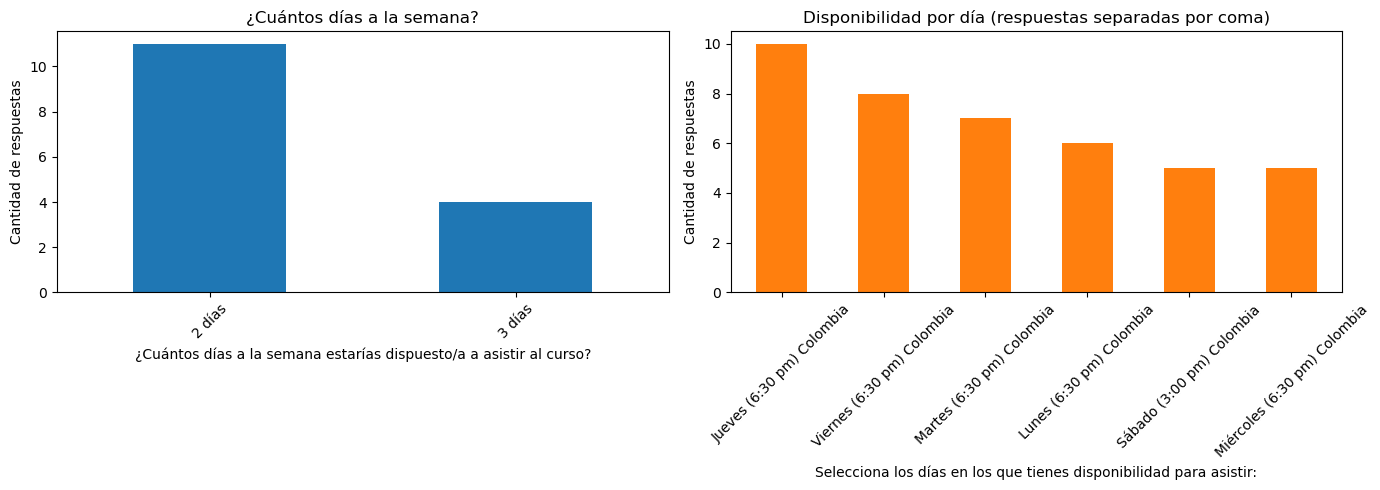

In [3]:
import matplotlib.pyplot as plt

col_days_count = "¿Cuántos días a la semana estarías dispuesto/a a asistir al curso?"
col_day_choices = "Selecciona los días en los que tienes disponibilidad para asistir:"

# Count responses for the first question (single choice)
counts_days = df[col_days_count].dropna().astype(str).str.strip().value_counts()

# Count responses for the second question (multiple choices separated by comma)
choices_series = df[col_day_choices].dropna().astype(str).str.split(',')
choices_exploded = choices_series.explode().str.strip()
counts_choices = choices_exploded[choices_exploded != ""].value_counts()

# Plot side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts_days.plot(kind='bar', ax=axes[0], color='C0', rot=45)
axes[0].set_title("¿Cuántos días a la semana?")
axes[0].set_ylabel("Cantidad de respuestas")

counts_choices.plot(kind='bar', ax=axes[1], color='C1', rot=45)
axes[1].set_title("Disponibilidad por día (respuestas separadas por coma)")
axes[1].set_ylabel("Cantidad de respuestas")

plt.tight_layout()
plt.show()